# 12 – Ternärdiagramme je Station

Vorlage ist die ÜZ-Folie „Analyse der Betriebsdaten ausgewählter HAST": drei Stationen als Punktwolke im Dreieck aus Leistung, Volumenstrom und Spreizung, eingefärbt nach Performance (kWh/m³).

Was hier passiert:

- gleiche Darstellung für alle 100 Stationen statt nur drei
- je Station sechs Panels: Begehung (vorher / Umbauphase / nachher) und Saison (Winter / Übergang / Sommer)
- alles auf Stunden- und auf Tagesebene

Knapp 200 Bilder schaut sich niemand einzeln an. Deshalb gibt es je Panel drei Kennzahlen:

- Schwerpunkt der Wolke
- Streubreite
- Anteil der Leistungsmodulation über Durchfluss bzw. über Spreizung

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import load_begehungen as lb
from src import ternaer as tn

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 30)

METER_DIR = ROOT / "data" / "processed" / "real_meters"
OUT_DIR = ROOT / "outputs" / "ternaer"
MIN_PUNKTE = 30

t0 = time.time()


def tick(txt):
    print(f"[{time.time() - t0:6.0f}s] {txt}", flush=True)

## 1 Rechenbasis

- Stundenreihen aus `data/processed/real_meters` (ohne ODS-Nachlieferung)
- Begehungsdatum aus der Monteurtabelle
- bei den zwei Stationen mit mehreren Terminen zählt der erste

In [2]:
serien = tn.lade_serien(METER_DIR)
termine = lb.begehung_dates_by_meter(available=set(serien))
begehungsdatum = {m: sorted(d)[0] for m, d in termine.items() if d}
mehrfach = [m for m, d in termine.items() if len(d) > 1]

von = min(d.index[0] for d in serien.values() if len(d))
bis = max(d.index[-1] for d in serien.values() if len(d))
tick(f"{len(serien)} Zaehlerreihen, {von:%Y-%m-%d} bis {bis:%Y-%m-%d}")
print(f"Begehungsdatum fuer {len(begehungsdatum)} Zaehler, "
      f"{len(mehrfach)} davon mit mehr als einem Termin")

[     8s] 100 Zaehlerreihen, 2021-05-31 bis 2025-07-11
Begehungsdatum fuer 56 Zaehler, 2 davon mit mehr als einem Termin


## 2 Was im Dreieck steht

**Normierung:**

- jeder Kanal wird auf das 95. Perzentil der eigenen Station normiert und auf [0, 1] gekappt
- danach werden die drei Werte auf Summe 1 gebracht
- normiert wird über die ganze Historie der Station, damit die Panels untereinander vergleichbar bleiben

Das Diagramm sagt dadurch nichts über die Größe der Station, nur über das Regelverhalten.

**Modulationsanteile:**

Aus P = c · V · ΔT folgt log P = log V + log ΔT + const. Die Varianz der Leistung zerfällt damit in zwei Teile:

    cov(log P, log V) / var(log P) + cov(log P, log ΔT) / var(log P) = 1

- `anteil_mod_flow` nahe 1: Station regelt über den Volumenstrom
- `anteil_mod_dt` nahe 1: Volumenstrom fast konstant, geregelt wird über die Spreizung
- Werte außerhalb [0, 1]: beide Kanäle laufen gegenläufig
- `summe_mod` ist die Kontrolle und muss 1 ergeben

Auf Tagesebene stimmt die Summe per Konstruktion, auf Stundenebene ist sie ein echter Test der Messkanäle.

In [3]:
#Zwei Gegenbeispiele: 68956351 ist die Station mit dem ueber Jahre
#offenen Ventil, 69631918 laeuft unauffaellig
BEISPIEL_AUFFAELLIG = 68956351
BEISPIEL_UNAUFFAELLIG = 69631918

beispiele = {}
for meter in (BEISPIEL_AUFFAELLIG, BEISPIEL_UNAUFFAELLIG):
    for aufl in ("stunde", "tag"):
        beispiele[(meter, aufl)] = tn.stationstabelle(
            serien[meter], meter, aufloesung=aufl,
            begehungsdatum=begehungsdatum.get(meter))

zeilen = []
for (meter, aufl), tab in beispiele.items():
    z = tn.modulationszerlegung(tab)
    z.update({"meter": meter, "aufloesung": aufl})
    zeilen.append(z)
print(pd.DataFrame(zeilen)[["meter", "aufloesung", "n", "anteil_mod_flow",
                            "anteil_mod_dt", "summe_mod"]].round(3).to_string(index=False))

   meter aufloesung     n  anteil_mod_flow  anteil_mod_dt  summe_mod
68956351     stunde 10281           -0.005          1.018      1.013
68956351        tag   971           -0.185          1.185      1.000
69631918     stunde 11576            1.081         -0.079      1.002
69631918        tag   766            0.597          0.403      1.000


- Kontrollsumme: Tagesebene exakt 1,000, Stundenebene 1,013 bzw. 1,002. Die Messkanäle passen zusammen.
- 68956351 regelt fast nur über die Spreizung.
- 69631918 regelt auf Stundenebene fast nur über den Durchfluss, auf Tagesebene gemischt (0,60 zu 0,40), weil der Tagesgang beim Mitteln verschwindet.
- Die Anteile hängen also von der Auflösung ab.

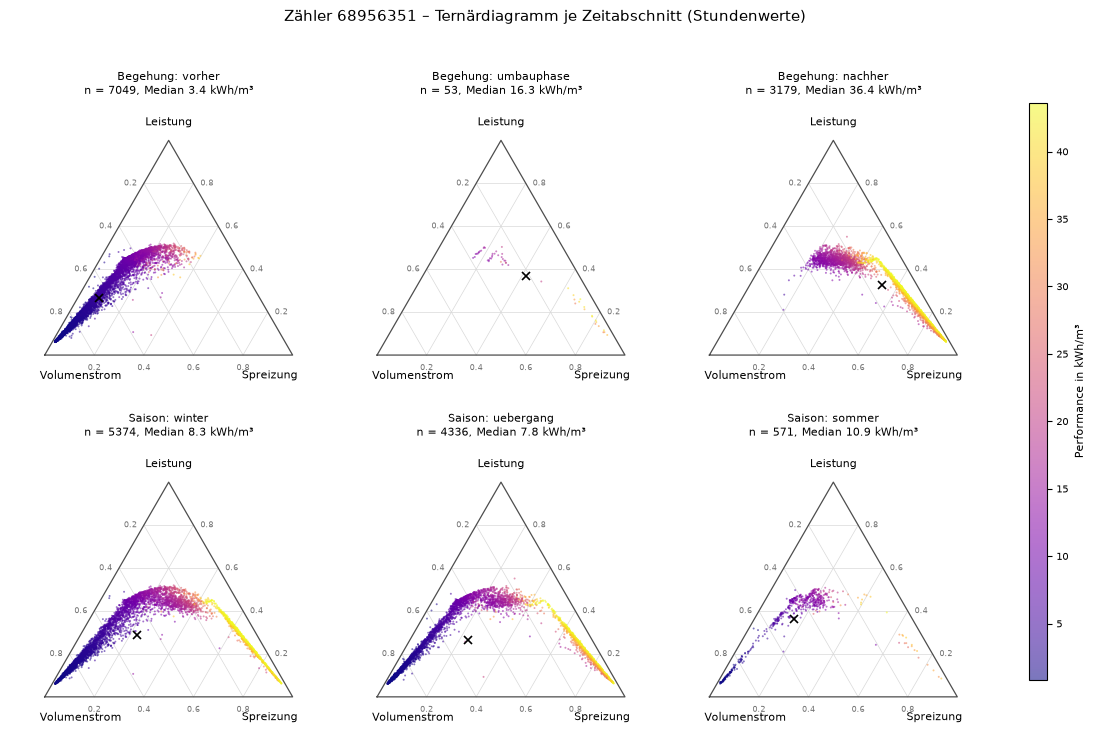

In [4]:
fig = tn.stationsgrafik(beispiele[(BEISPIEL_AUFFAELLIG, "stunde")],
                        BEISPIEL_AUFFAELLIG, aufloesung="Stundenwerte")
plt.show()

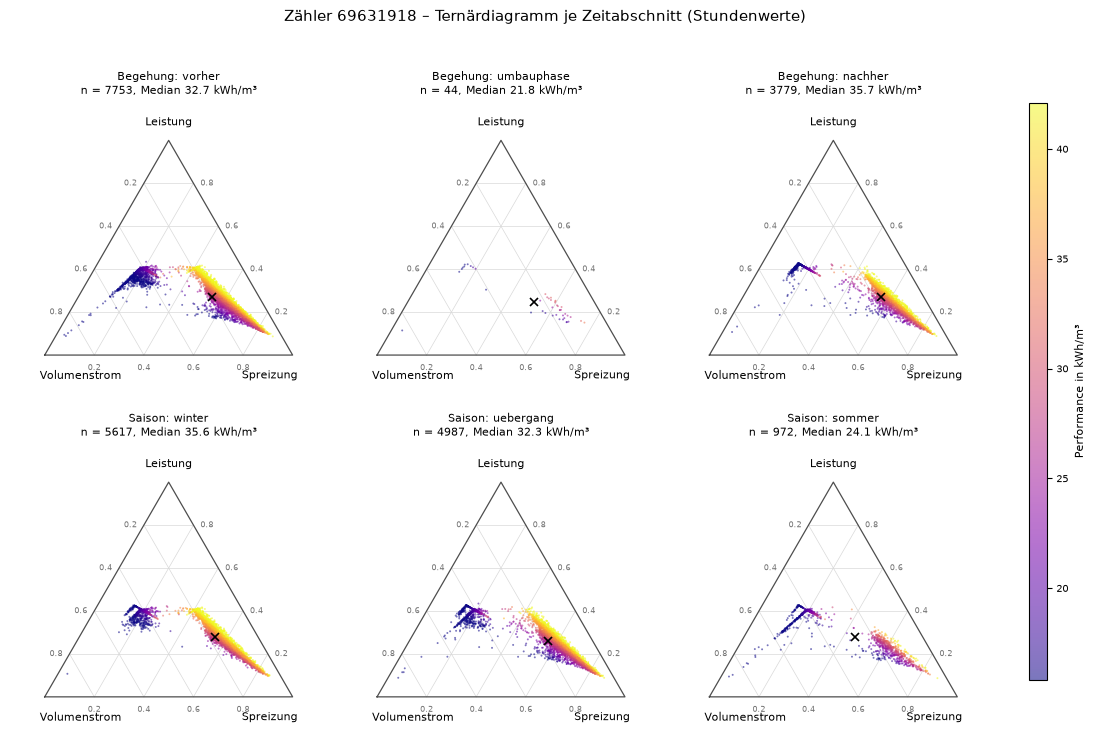

In [5]:
fig = tn.stationsgrafik(beispiele[(BEISPIEL_UNAUFFAELLIG, "stunde")],
                        BEISPIEL_UNAUFFAELLIG, aufloesung="Stundenwerte")
plt.show()

**Auffällige Station (68956351):**

- breite dunkle Fahne zur Durchfluss-Ecke: viel Wasser, kleine Spreizung, unter 5 kWh/m³
- Begehung: vorher 3,4 kWh/m³ (7.049 Stunden), nachher 36,4 kWh/m³ (3.179 Stunden). Die Wolke wechselt praktisch komplett die Seite.
- Passt zu einer Ventilreparatur beim Begehungstermin. Das Ventil stand laut Begehungshistorie über drei Jahre offen.
- Im Saisonschnitt wandert die Wolke vom Winter zum Sommer deutlich zur Durchfluss-Ecke.

**Unauffällige Station (69631918):**

- zwei getrennte Wolken, Schwachlast und Volllast derselben Anlage. Kein Defekt.
- im Saisonschnitt kaum Verschiebung

**Einschränkung:** Alle Panels einer Station hängen am selben 95. Perzentil. Bei einem Regimewechsel wie bei 68956351 drückt der hohe Durchfluss von vorher die Punkte danach an den Rand, und die Saisonpanels mischen beide Phasen.

## 3 Export über alle Stationen

- `ternaer.exportiere` schreibt je Station und Auflösung ein PNG nach `outputs/ternaer/` und liefert die Kennzahlen aller Panels
- dauert ein paar Minuten
- Stationen und Panels ohne verwertbare Punkte stehen mit n = 0 in der Tabelle

In [6]:
kenn = tn.exportiere(serien, OUT_DIR, begehungsdatum=begehungsdatum,
                     fortschritt=False)
tick(f"{kenn.shape[0]} Panelzeilen, Bilder unter {OUT_DIR.relative_to(ROOT)}")
print(kenn.groupby(["aufloesung", "schnitt"])["n"]
      .agg(leer=lambda s: int((s == 0).sum()), median="median").to_string())

[   345s] 1200 Panelzeilen, Bilder unter outputs\ternaer
                     leer  median
aufloesung schnitt               
stunde     begehung   164     0.0
           saison      19  2685.0
tag        begehung   168     0.0
           saison      11   193.5


In [7]:
#Kontrollrechnung ueber alle Panels: die Zerlegung muss sich zu 1 addieren
kontrolle = kenn.dropna(subset=["summe_mod"])
print(f"summe_mod ueber {len(kontrolle)} Panels: "
      f"min {kontrolle['summe_mod'].min():.4f}, "
      f"max {kontrolle['summe_mod'].max():.4f}")
print(f"Panels mit Abweichung ueber 5 Prozent: "
      f"{int((kontrolle['summe_mod'].sub(1).abs() > 0.05).sum())}")

summe_mod ueber 776 Panels: min 0.9712, max 1.0958
Panels mit Abweichung ueber 5 Prozent: 1


## 4 Wie moduliert das Teilnetz?

- nur das Winterpanel, im Sommer gibt es kaum Modulation
- Panels unter 30 Punkten bleiben draußen

In [8]:
def winterpanel(aufl):
    m = ((kenn["aufloesung"] == aufl) & (kenn["schnitt"] == "saison")
         & (kenn["gruppe"] == tn.GRUPPE_WINTER) & (kenn["n"] >= MIN_PUNKTE))
    return kenn[m].dropna(subset=["anteil_mod_dt", "performance_median"])


for aufl in ("stunde", "tag"):
    w = winterpanel(aufl)
    dt_dom = int((w["anteil_mod_dt"] > 0.6).sum())
    flow_dom = int((w["anteil_mod_flow"] > 0.6).sum())
    print(f"{aufl}: {len(w)} Stationen, davon {flow_dom} durchfluss- und "
          f"{dt_dom} spreizungsdominiert, {len(w) - dt_dom - flow_dom} gemischt")
    print(w[["anteil_mod_dt", "streuung", "schwerpunkt_dt",
             "performance_median"]].describe().loc[
        ["mean", "std", "min", "50%", "max"]].round(3).to_string())
    print()

stunde: 94 Stationen, davon 74 durchfluss- und 12 spreizungsdominiert, 8 gemischt
      anteil_mod_dt  streuung  schwerpunkt_dt  performance_median
mean          0.198     0.116           0.407              29.663
std           0.331     0.045           0.085              10.473
min          -0.383     0.024           0.228               7.094
50%           0.103     0.112           0.410              30.296
max           1.127     0.255           0.603              47.450

tag: 98 Stationen, davon 72 durchfluss- und 11 spreizungsdominiert, 15 gemischt
      anteil_mod_dt  streuung  schwerpunkt_dt  performance_median
mean          0.184     0.064           0.367              27.161
std           0.463     0.043           0.048               9.375
min          -1.123     0.015           0.246               5.612
50%           0.106     0.047           0.369              28.584
max           2.002     0.225           0.581              45.876



- Das Teilnetz ist klar durchflussgeregelt: 74 von 94 Stationen modulieren im Winter überwiegend über den Volumenstrom, nur 12 über die Spreizung.
- Die Streubreite ist auf Stundenebene (0,116) etwa doppelt so groß wie auf Tagesebene (0,064), weil dort der Tagesgang rausfällt.

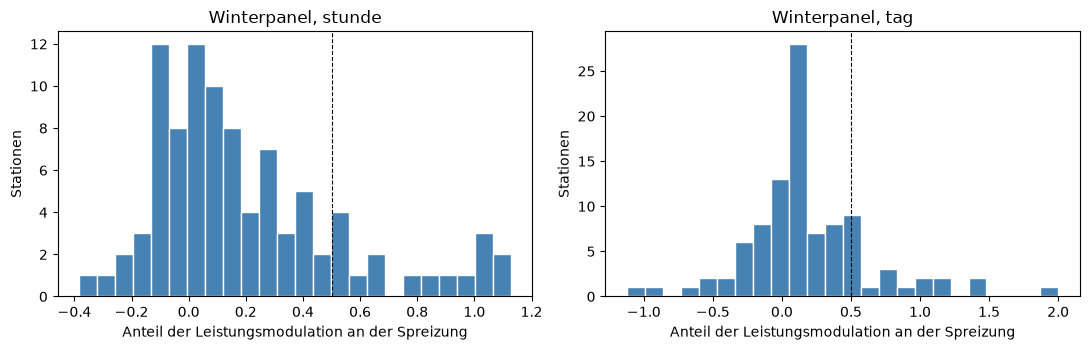

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, aufl in zip(axes, ("stunde", "tag")):
    w = winterpanel(aufl)
    ax.hist(w["anteil_mod_dt"], bins=24, color="steelblue", edgecolor="white")
    ax.axvline(0.5, color="black", lw=0.8, ls="--")
    ax.set_title(f"Winterpanel, {aufl}")
    ax.set_xlabel("Anteil der Leistungsmodulation an der Spreizung")
    ax.set_ylabel("Stationen")
fig.tight_layout()
plt.show()

## 5 Hängt die Modulationsart mit der Effizienz zusammen?

Laut Folie ist Spreizungsmodulation das Merkmal der effizienten Station, Durchflussmodulation das der ineffizienten. Das lässt sich prüfen.

In [10]:
for aufl in ("stunde", "tag"):
    w = winterpanel(aufl)
    for spalte in ("anteil_mod_dt", "streuung", "schwerpunkt_dt"):
        rho, p = stats.spearmanr(w[spalte], w["performance_median"])
        print(f"{aufl:7s} rho({spalte:16s}, performance) = {rho:+.3f}  p = {p:.2g}")
    print()

stunde  rho(anteil_mod_dt   , performance) = -0.480  p = 9.8e-07
stunde  rho(streuung        , performance) = -0.226  p = 0.029
stunde  rho(schwerpunkt_dt  , performance) = +0.773  p = 6.5e-20

tag     rho(anteil_mod_dt   , performance) = -0.379  p = 0.00012
tag     rho(streuung        , performance) = -0.300  p = 0.0027
tag     rho(schwerpunkt_dt  , performance) = +0.526  p = 2.6e-08



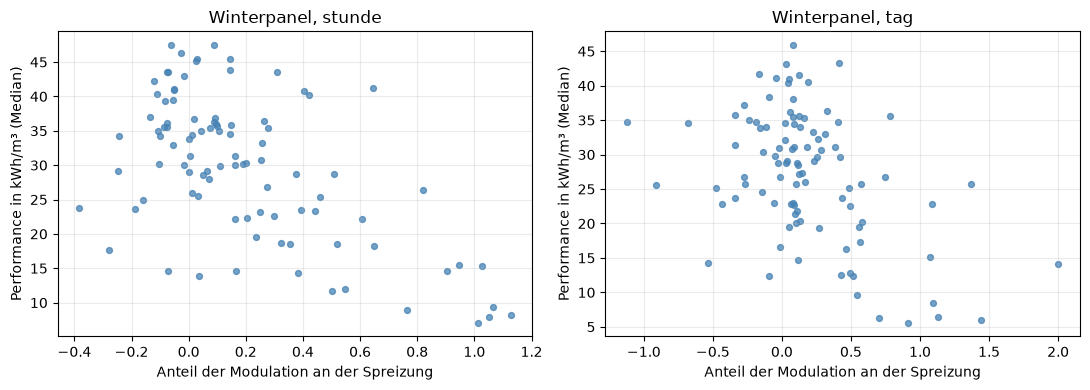

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
for ax, aufl in zip(axes, ("stunde", "tag")):
    w = winterpanel(aufl)
    ax.scatter(w["anteil_mod_dt"], w["performance_median"], s=18,
               color="steelblue", alpha=0.75)
    ax.set_title(f"Winterpanel, {aufl}")
    ax.set_xlabel("Anteil der Modulation an der Spreizung")
    ax.set_ylabel("Performance in kWh/m³ (Median)")
    ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

**Das Vorzeichen ist umgekehrt zur Folie:**

- Spreizungsanteil gegen Performance: ρ = −0,48 auf Stundenebene (p < 1e-6), −0,38 auf Tagesebene (p = 0,0001)
- je mehr eine Station über die Spreizung moduliert, desto schlechter ist sie

**Warum das plausibel ist:**

- wer bei sinkender Last den Volumenstrom drosselt, hält die Spreizung und den Rücklauf kalt
- wer den Volumenstrom konstant lässt, bekommt bei Teillast eine kleine Spreizung und warmen Rücklauf (festsitzendes Ventil)

**Zur Folie:** Vielleicht ist dort die Lage der Wolke gemeint und nicht die Richtung der Modulation. Die Lage auf der Spreizungsachse korreliert nämlich positiv (+0,77), ist aber fast dasselbe wie die Performance selbst. Die Streubreite bringt wenig (−0,23 bzw. −0,30).

## 6 Drei Archetypen

Zerfällt das Teilnetz wirklich in drei Gruppen wie auf der Folie? Geclustert wird über Schwerpunkt, Streubreite und Modulationsanteil des Winterpanels.

In [12]:
FEATURES = ["anteil_mod_dt", "streuung", "schwerpunkt_dt", "schwerpunkt_power"]

for aufl in ("stunde", "tag"):
    w = winterpanel(aufl).dropna(subset=FEATURES)
    X = StandardScaler().fit_transform(w[FEATURES])
    sil = {k: round(silhouette_score(X, KMeans(k, n_init=10, random_state=42)
                                     .fit_predict(X)), 3)
           for k in range(2, 7)}
    print(f"{aufl}: Silhouette je k {sil}")

stunde: Silhouette je k {2: 0.321, 3: 0.311, 4: 0.285, 5: 0.276, 6: 0.267}
tag: Silhouette je k {2: 0.527, 3: 0.397, 4: 0.38, 5: 0.304, 6: 0.309}


In [13]:
w = winterpanel("stunde").dropna(subset=FEATURES).copy()
X = StandardScaler().fit_transform(w[FEATURES])
w["archetyp"] = KMeans(3, n_init=10, random_state=42).fit_predict(X)
profil = w.groupby("archetyp")[FEATURES + ["performance_median"]].median()
profil["stationen"] = w["archetyp"].value_counts().sort_index()
print(profil.round(3).to_string())
print()
for a in sorted(w["archetyp"].unique()):
    beispiel = w[w["archetyp"] == a].nlargest(3, "n")["meter"].tolist()
    print(f"Archetyp {a}: Beispielzaehler {beispiel}")

          anteil_mod_dt  streuung  schwerpunkt_dt  schwerpunkt_power  performance_median  stationen
archetyp                                                                                           
0                 0.299     0.082           0.346              0.323              23.551         30
1                 0.025     0.113           0.446              0.282              35.006         55
2                 0.947     0.158           0.262              0.272               9.420          9

Archetyp 0: Beispielzaehler [68956355, 68956367, 72167783]
Archetyp 1: Beispielzaehler [72167791, 72135481, 68956345]
Archetyp 2: Beispielzaehler [69513891, 68956351, 72167777]


| Gruppe | Median Performance |
|---|---|
| regelt fast nur über Durchfluss | 35,0 kWh/m³ |
| gemischt | 23,6 kWh/m³ |
| regelt fast nur über Spreizung | 9,4 kWh/m³ |

- Faktor 3,7 zwischen bester und schlechtester Gruppe
- Silhouette bei k=3 nur 0,311 (k=2: 0,321). Das ist eher ein Gefälle als drei saubere Typen, wie schon in Notebook 01 und 04.
- Zähler 68956351 (das offene Ventil) landet in der schlechtesten Gruppe, ganz ohne Label.

## 7 Bewegen sich die Stationen durch die Begehung?

- jede Station gegen sich selbst, vorher gegen nachher
- ±7 Tage um die Begehung bleiben draußen
- gepaarter Vorzeichenrangtest

In [14]:
v = kenn[(kenn["schnitt"] == "begehung")
         & (kenn["gruppe"].isin([tn.GRUPPE_VORHER, tn.GRUPPE_NACHHER]))
         & (kenn["n"] >= MIN_PUNKTE)]
paare = v.pivot_table(index=["meter", "aufloesung"], columns="gruppe",
                      values=["anteil_mod_dt", "performance_median",
                              "streuung", "schwerpunkt_dt"]).dropna()

zeilen = []
for aufl in ("stunde", "tag"):
    q = paare.xs(aufl, level="aufloesung")
    for groesse in ("anteil_mod_dt", "schwerpunkt_dt", "performance_median",
                    "streuung"):
        d = q[(groesse, tn.GRUPPE_NACHHER)] - q[(groesse, tn.GRUPPE_VORHER)]
        zeilen.append({"aufloesung": aufl, "groesse": groesse, "n": len(d),
                       "median_differenz": round(float(d.median()), 3),
                       "anteil_positiv": round(float((d > 0).mean()), 2),
                       "p_wilcoxon": round(float(stats.wilcoxon(d).pvalue), 4)})
print(pd.DataFrame(zeilen).to_string(index=False))

aufloesung            groesse  n  median_differenz  anteil_positiv  p_wilcoxon
    stunde      anteil_mod_dt 41             0.022            0.56      0.5127
    stunde     schwerpunkt_dt 41            -0.016            0.37      0.0452
    stunde performance_median 41             0.349            0.51      0.1767
    stunde           streuung 41            -0.004            0.37      0.0654
       tag      anteil_mod_dt 41            -0.008            0.44      0.3892
       tag     schwerpunkt_dt 41            -0.028            0.34      0.1633
       tag performance_median 41             1.142            0.66      0.0075
       tag           streuung 41            -0.010            0.27      0.0002


**Modulationsart:** ändert sich nicht.

- Spreizungsanteil im Median +0,022 (Stunde, p = 0,51) bzw. −0,008 (Tag, p = 0,39)
- etwa die Hälfte der Stationen bewegt sich in die eine, die andere Hälfte in die andere Richtung

**Niveau:** bewegt sich.

- Performance auf Tagesebene im Median +1,14 kWh/m³ (p = 0,0075)
- Wolke wird enger: Streubreite −0,010 (p = 0,0002)
- passt zu Notebook 08: Verschiebung nach oben, gleiche Kennlinienform

Ohne Kontrollgruppe bleibt es bei „passt zu einer Wirkung der Begehung". Auf Stundenebene ist der Effekt bei denselben 41 Stationen nicht signifikant (p = 0,18), dort steckt der Tagesgang als Rauschen drin.

## 8 Stunde oder Tag?

In [15]:
vergleich = []
for aufl in ("stunde", "tag"):
    w = winterpanel(aufl)
    rho, p = stats.spearmanr(w["anteil_mod_dt"], w["performance_median"])
    q = paare.xs(aufl, level="aufloesung")
    d = (q[("performance_median", tn.GRUPPE_NACHHER)]
         - q[("performance_median", tn.GRUPPE_VORHER)])
    vergleich.append({
        "aufloesung": aufl,
        "stationen_winter": len(w),
        "punkte_median": int(w["n"].median()),
        "streuung_median": round(float(w["streuung"].median()), 3),
        "rho_mod_perf": round(rho, 3),
        "p_begehung_perf": round(float(stats.wilcoxon(d).pvalue), 4),
    })
print(pd.DataFrame(vergleich).to_string(index=False))

aufloesung  stationen_winter  punkte_median  streuung_median  rho_mod_perf  p_begehung_perf
    stunde                94           3358            0.112        -0.480           0.1767
       tag                98            181            0.047        -0.379           0.0075


- **Stundenebene:** besser für den Zusammenhang Modulationsart und Effizienz (ρ = −0,48 gegen −0,38). Für die Diagnose einer einzelnen Station.
- **Tagesebene:** besser für vorher/nachher (p = 0,0075 gegen 0,18). Für den Vergleich zweier Zeiträume.
- Nachteil der Stundenbilder: die Farbe ist die momentane Spreizung und damit fast dasselbe wie die ΔT-Achse.

## Zusammenfassung

**Belastbar:**

- Die Zerlegung der Modulation funktioniert: Kontrollsumme über alle 776 Panels zwischen 0,971 und 1,096, nur ein Panel weicht um mehr als 5 % ab.
- Stationen, die über die Spreizung modulieren, sind schlechter (ρ = −0,48, p < 1e-6). Das ist umgekehrt zur Folie.
- Das Teilnetz ist überwiegend durchflussgeregelt (74 von 94).
- Die zwölf spreizungsdominierten Stationen sind die schlechteste Gruppe (Median 9,4 gegen 35,0 kWh/m³). Darunter ist Zähler 68956351.

**Schwach:**

- Die drei Archetypen sind ein Gefälle, keine getrennten Klassen (Silhouette 0,311). Als Rangskala okay, als Klassifikation nicht.

**Negativbefund:**

- Die Modulationsart ändert sich durch die Begehung nicht (p = 0,51 bzw. 0,39), obwohl Performance und Streubreite besser werden. Als Erfolgsmaß für Begehungen taugt der Modulationsanteil nicht.

**Offen:**

- Widerspruch zur Folienbeschriftung mit der ÜZ klären
- Normierung auf das 95. Perzentil ist gesetzt, nicht geprüft. Alternative wäre der Anschlusswert aus `Nodes_Edges.ods`.
- Die Grenze 0,6 für „dominiert" ist willkürlich.